In [1]:
import os
import cv2
import msgpack
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Dropout
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

2026-05-02 10:05:04.629137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777716305.166453      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777716305.284074      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777716306.269410      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777716306.269452      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777716306.269455      57 computation_placer.cc:177] computation placer alr

In [2]:
print(os.listdir('/kaggle/input/datasets/habedi/large-dataset-of-geotagged-images'))

['shards']


In [5]:
dataset_path = '/kaggle/input/datasets/habedi/large-dataset-of-geotagged-images'

for root, dirs, files in os.walk(dataset_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-"*50)

ROOT: /kaggle/input/datasets/habedi/large-dataset-of-geotagged-images
DIRS: ['shards']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/datasets/habedi/large-dataset-of-geotagged-images/shards
DIRS: []
FILES: ['shard_24.msg', 'shard_25.msg', 'shard_139.msg', 'shard_74.msg', 'shard_66.msg']
--------------------------------------------------


In [6]:
file_path = "/kaggle/input/datasets/habedi/large-dataset-of-geotagged-images/shards/shard_24.msg"

with open(file_path, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)

    for i, data in enumerate(unpacker):
        print(type(data))
        print(data)

        if i == 0:
            break

<class 'dict'>
{'image': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\x08\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x01@\x02\x02\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\

In [7]:
file_path = "/kaggle/input/datasets/habedi/large-dataset-of-geotagged-images/shards/shard_24.msg"

with open(file_path, "rb") as f:

    unpacker = msgpack.Unpacker(f, raw=False)

    first_item = next(unpacker)

print(first_item.keys())

dict_keys(['image', 'id', 'latitude', 'longitude'])


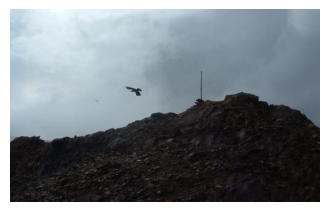

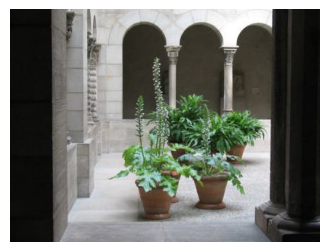

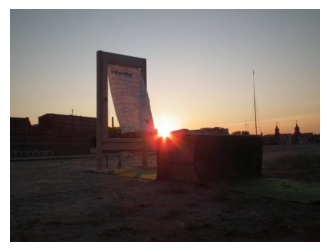

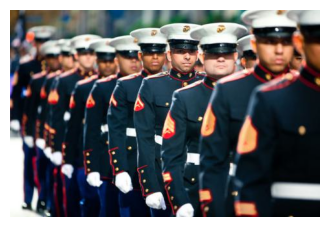

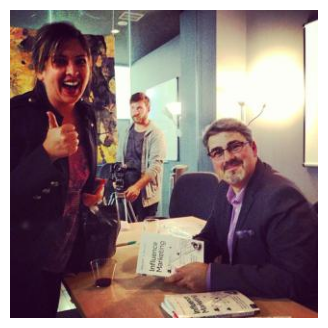

In [8]:
with open(file_path, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)

    for i, item in enumerate(unpacker):
        image_bytes = item['image']
        image_array = np.frombuffer(image_bytes, np.uint8)
        
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(4,4))
        plt.imshow(image)
        plt.axis('off')
        plt.show()

        if i == 4:
            break

In [9]:
import msgpack
import numpy as np
import cv2

images = []
targets = []
limit = 1000   

with open(file_path, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)

    for i, item in enumerate(unpacker):
        image_bytes = item['image']
        image_array = np.frombuffer(image_bytes, np.uint8)
        
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        image = cv2.resize(image, (128,128))
        image = image.astype('float32') / 255.0
        images.append(image)

        targets.append([
            item['latitude'],
            item['longitude']
        ])

        if i >= limit:
            break

X = np.array(images, dtype='float32')
y = np.array(targets, dtype='float32')

print(X.shape)
print(y.shape)

(1001, 128, 128, 3)
(1001, 2)


In [11]:
y[:,0] = (y[:,0] + 90) / 180
y[:,1] = (y[:,1] + 180) / 360

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = Sequential()

model.add(Conv2D(
    96,
    kernel_size=(11,11),
    strides=4,
    padding='same',
    activation='relu',
    input_shape=(128,128,3)
))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

model.add(Conv2D(
    256,
    kernel_size=(5,5),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

model.add(Conv2D(
    384,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(Conv2D(
    384,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(Conv2D(
    256,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(GlobalAveragePooling2D())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777716426.328576      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777716426.334702      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 15, 15, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,016,130 (15.32 MB)

 Trainable params: 4,013,378 (15.31 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [16]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

In [18]:
model.compile(
    loss = 'mse',
    optimizer = 'adam',
    metrics = ['mae']
)

In [19]:
history1 = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/50


I0000 00:00:1777716459.890367     136 service.cc:152] XLA service 0x7fd1e400b120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777716459.890415     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777716459.890423     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777716460.708439     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


 5/25 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0205 - mae: 0.1109

I0000 00:00:1777716467.677450     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - loss: 0.0223 - mae: 0.1154 - val_loss: 0.1882 - val_mae: 0.4277 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0087 - mae: 0.0650 - val_loss: 0.0056 - val_mae: 0.0641 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0035 - mae: 0.0378 - val_loss: 8.2138e-05 - val_mae: 0.0071 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 8.9833e-04 - mae: 0.0212 - val_loss: 1.6764e-05 - val_mae: 0.0034 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.0661e-04 - mae: 0.0159 - val_loss: 1.1350e-05 - val_mae: 0.0029 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.8730e-04 - mae: 0.0117
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.8547e-04 - mae: 0.0117 - val_loss: 7.6484e-06 - val_mae: 0.0025 - learning

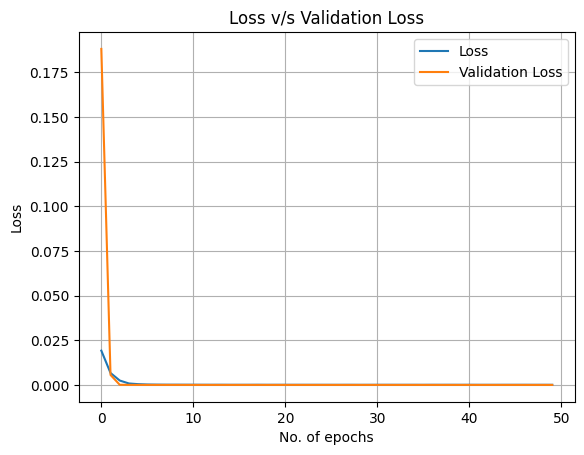

In [20]:
plt.plot(history1.history['loss'], label='Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('No. of epochs')
plt.ylabel('Loss')
plt.title('Loss v/s Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

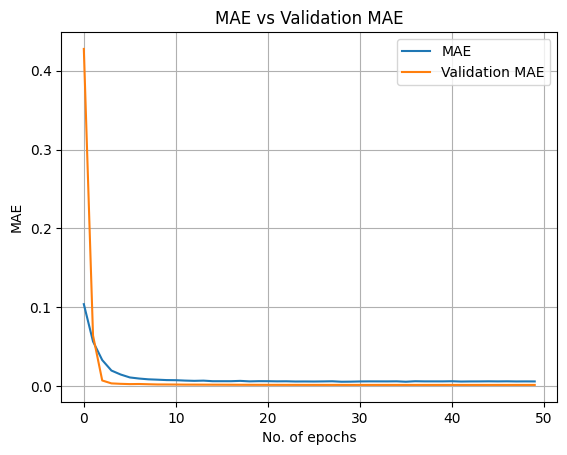

In [21]:
plt.plot(history1.history['mae'], label='MAE')
plt.plot(history1.history['val_mae'], label='Validation MAE')

plt.xlabel('No. of epochs')
plt.ylabel('MAE')
plt.title('MAE vs Validation MAE')

plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


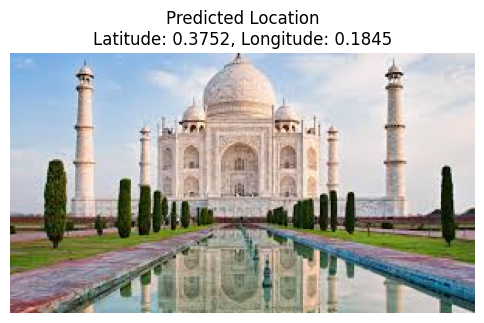

Predicted Latitude : 0.37522125
Predicted Longitude: 0.18450928


In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/kaggle/input/datasets/aarushkhandelwal/geo-vision-test-data/test imags (GeoVision)/test_image_geo_vision8.jpeg"   

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128,128))

img_normalized = img_resized.astype('float32') / 255.0
img_input = np.expand_dims(img_normalized, axis=0)


prediction = model.predict(img_input)
pred_lat = prediction[0][0]
pred_lon = prediction[0][1]

pred_lat = pred_lat * 180 - 90
pred_lon = pred_lon * 360 - 180

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Predicted Location\nLatitude: {pred_lat:.4f}, Longitude: {pred_lon:.4f}")
plt.show()

print("Predicted Latitude :", pred_lat)
print("Predicted Longitude:", pred_lon)

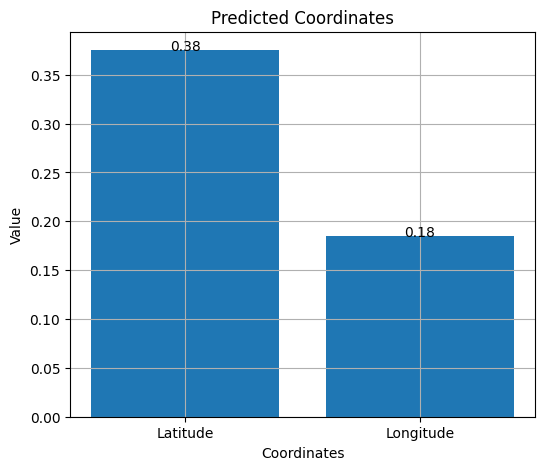

In [38]:
import matplotlib.pyplot as plt

labels = ['Latitude', 'Longitude']
values = [pred_lat, pred_lon]

plt.figure(figsize=(6,5))
plt.bar(labels, values)
plt.xlabel('Coordinates')
plt.ylabel('Value')
plt.title('Predicted Coordinates')

for i, v in enumerate(values):
    plt.text(i, v, f'{v:.2f}', ha='center')

plt.grid(True)
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

#       Actual Lat   Actual Lon     Pred Lat     Pred Lon    Error(km)
1          25.2757      55.3217      19.7514     -29.4624       8583.5
2          26.1189     -80.1442      28.9090     -37.8927       4156.6
3          45.4659      15.4797      33.5981     -13.0099       2756.0
4          23.1354     -82.3589      34.8778     -19.4039       6161.4
5          13.2732     103.8217      30.1405     -10.7899      11520.5
6          45.8910       7.7435      18.7889      -6.6519       3291.2
7         -33.8738     151.2055      30.4249       0.8241      17210.2
8          22.5449     120.3243      30.3777      -7.7793      11934.0
9          35.3595     -82.5555      22.3971       0.5388       7991.7
10         53.4038      -1.5039      21.9006      -1.4785       3503.0
11         43.1558      -5.4113      28.5924     -46.4376       3986.2
12         47.4897       7.7315      21.7498      -9.0549       3232.4
13         49.3096    -124.5437      1

/tmp/ipykernel_57/3353737612.py:201: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3353737612.py:201: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3353737612.py:201: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3353737612.py:202: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('actual_vs_predicted_samples.png', bbox_inches='tight', dpi=150)
/tmp/ipykernel_57/3353737612.py:202: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('actual_vs_predicted_samples.png', bbox_inches='tight', dpi=150)
/tmp/ipykernel_57/3353737612.py:202: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.savefig('actual_vs_predicted_samples.png', bbox_i

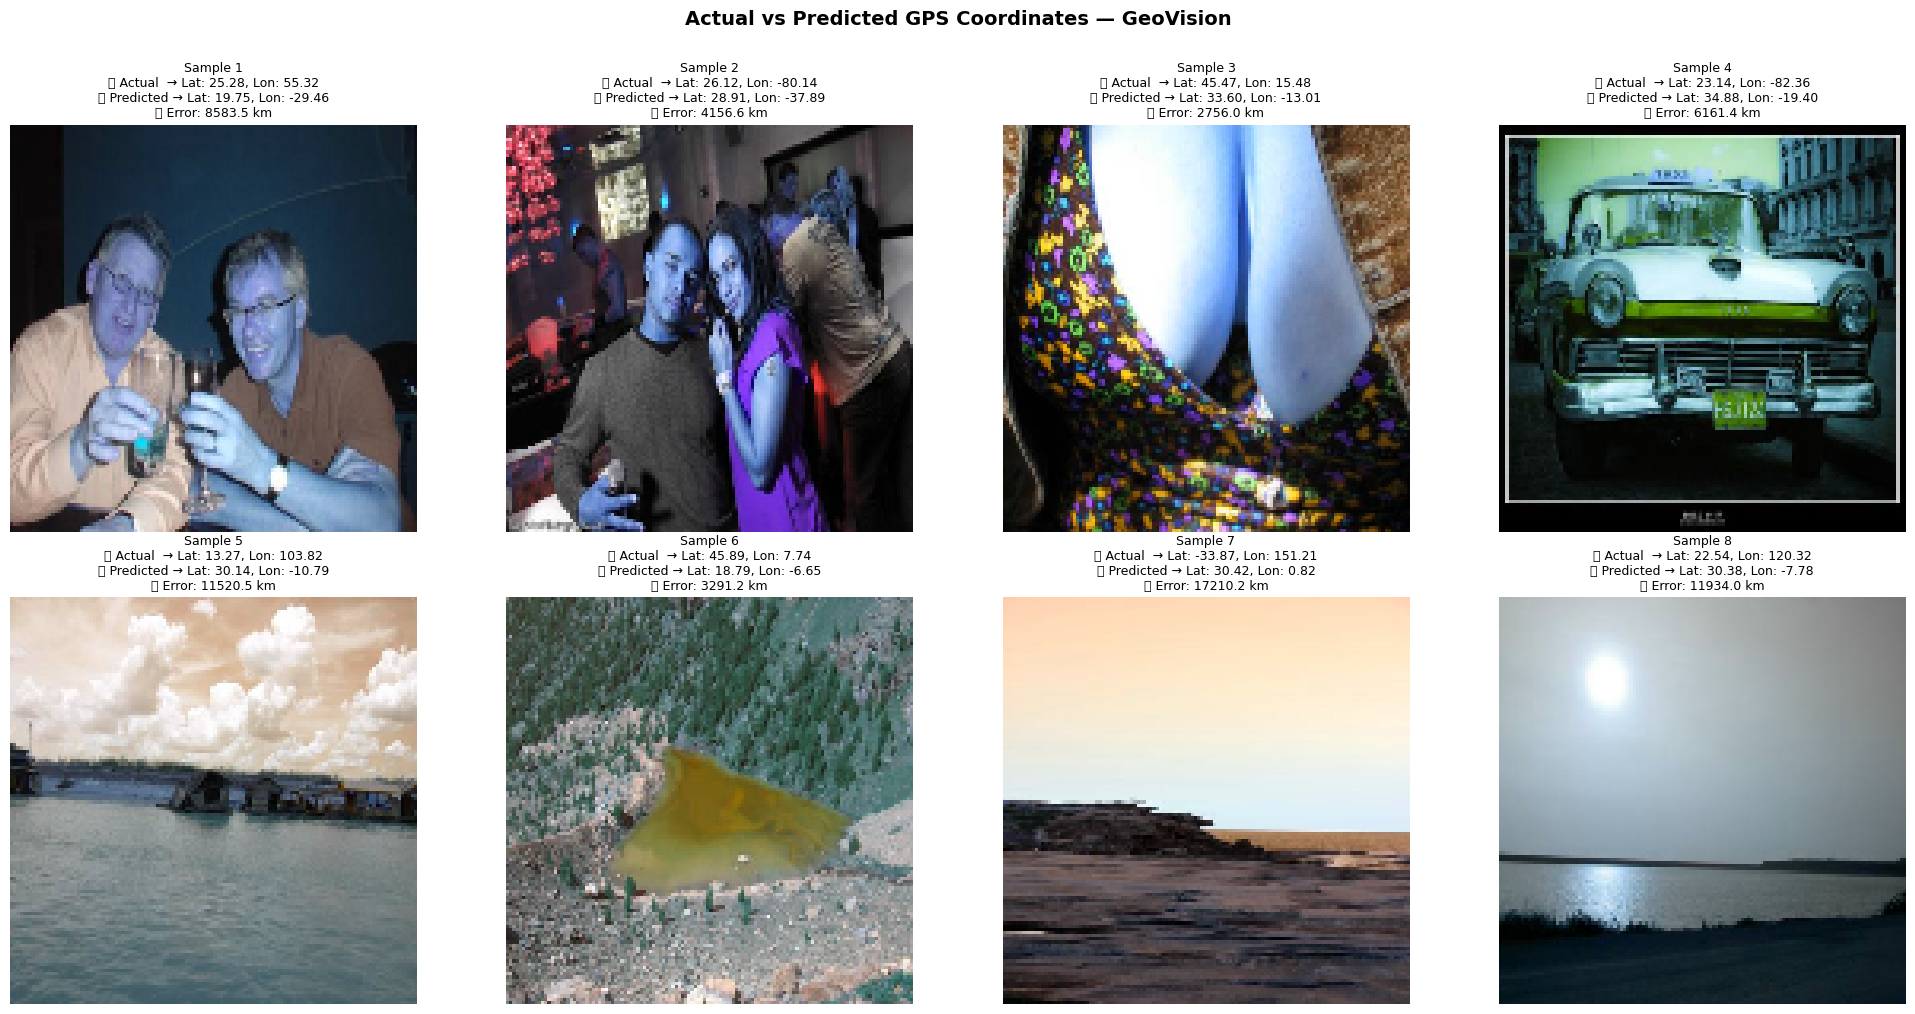

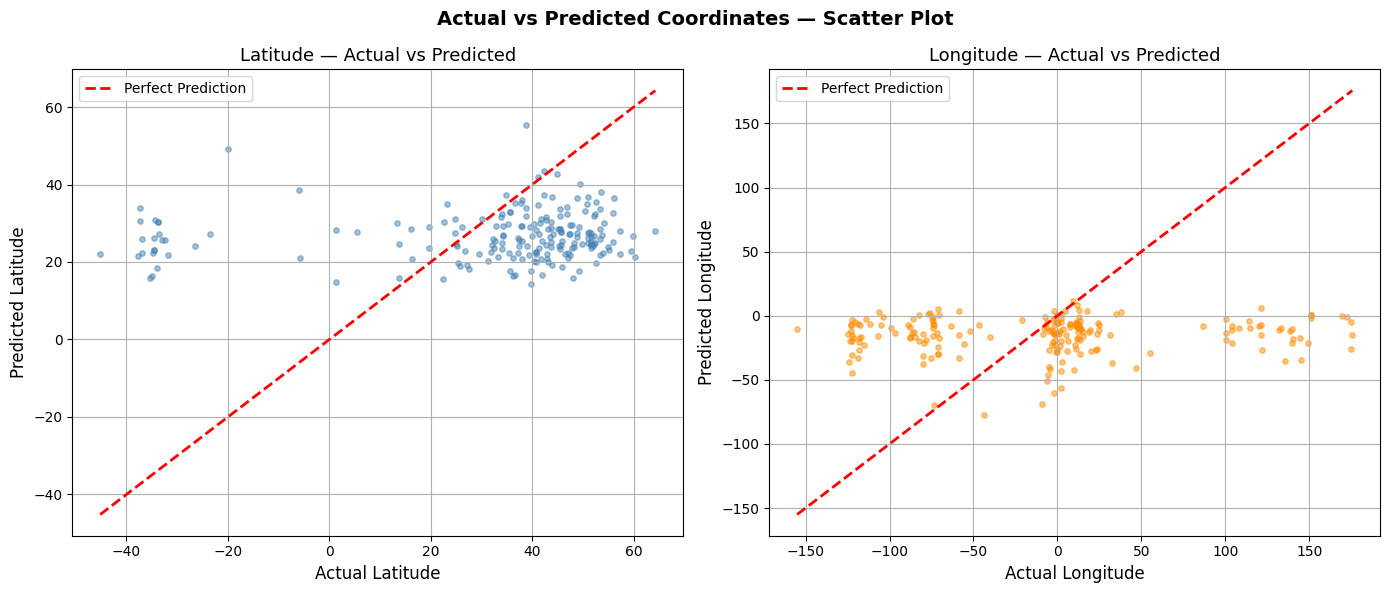

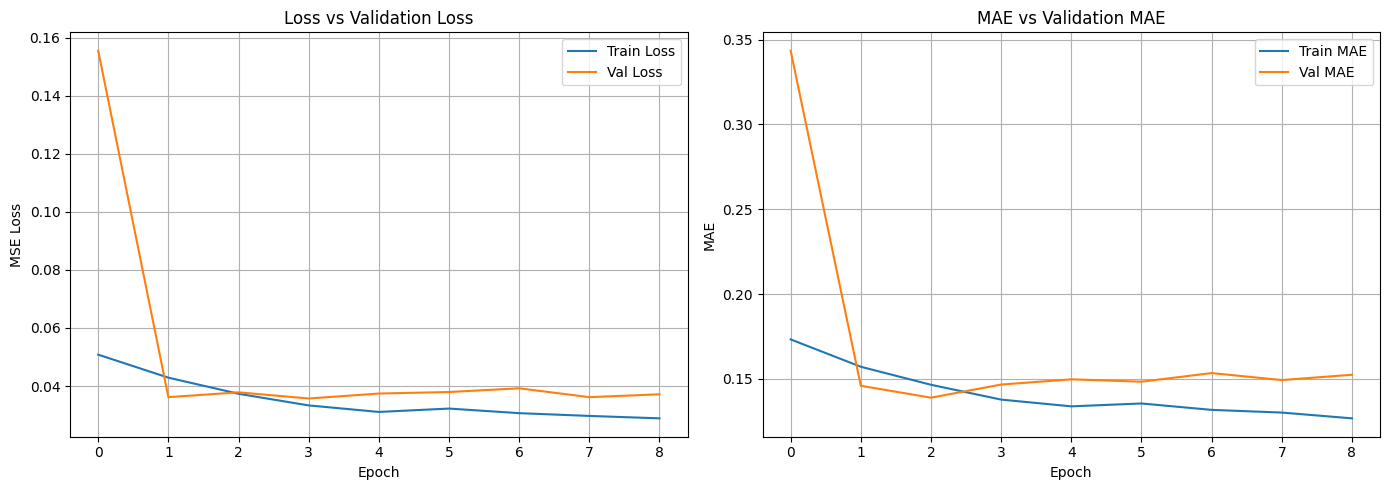


✅ Done! Files saved:
   → actual_vs_predicted_samples.png
   → scatter_actual_vs_predicted.png
   → training_curves.png


In [43]:

import math

# STEP 6 — HAVERSINE DISTANCE (km)
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371   # Earth radius in km
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a    = (math.sin(dlat/2)**2 +
            math.cos(math.radians(lat1)) *
            math.cos(math.radians(lat2)) *
            math.sin(dlon/2)**2)
    return R * 2 * math.asin(math.sqrt(a))


predictions = model.predict(X_test)
pred_lats = predictions[:, 0] * 180 - 90
pred_lons = predictions[:, 1] * 360 - 180

actual_lats = y_orig_test[:, 0]
actual_lons  = y_orig_test[:, 1]

print("\n" + "="*75)
print(f"{'#':<5} {'Actual Lat':>12} {'Actual Lon':>12} {'Pred Lat':>12} {'Pred Lon':>12} {'Error(km)':>12}")
print("="*75)

total_error = 0
for i in range(len(X_test)):
    a_lat = actual_lats[i]
    a_lon = actual_lons[i]
    p_lat = pred_lats[i]
    p_lon = pred_lons[i]
    error = haversine_km(a_lat, a_lon, p_lat, p_lon)
    total_error += error
    print(f"{i+1:<5} {a_lat:>12.4f} {a_lon:>12.4f} {p_lat:>12.4f} {p_lon:>12.4f} {error:>12.1f}")

avg_error = total_error / len(X_test)
print("="*75)
print(f"{'Average Error (km)':<50} {avg_error:>12.1f}")
print("="*75)

num_samples = 8
fig, axes   = plt.subplots(2, 4, figsize=(20, 10))
axes        = axes.flatten()

for i in range(num_samples):
    img = (X_test[i] * 255).astype(np.uint8)   # denormalize image

    a_lat = actual_lats[i]
    a_lon  = actual_lons[i]
    p_lat  = pred_lats[i]
    p_lon  = pred_lons[i]
    error  = haversine_km(a_lat, a_lon, p_lat, p_lon)

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"Sample {i+1}\n"
        f"✅ Actual  → Lat: {a_lat:.2f}, Lon: {a_lon:.2f}\n"
        f"🔴 Predicted → Lat: {p_lat:.2f}, Lon: {p_lon:.2f}\n"
        f"📏 Error: {error:.1f} km",
        fontsize=9,
        loc='center'
    )

plt.suptitle("Actual vs Predicted GPS Coordinates — GeoVision",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('actual_vs_predicted_samples.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Latitude scatter ---
axes[0].scatter(actual_lats, pred_lats, alpha=0.5, color='steelblue', s=15)
axes[0].plot(
    [actual_lats.min(), actual_lats.max()],
    [actual_lats.min(), actual_lats.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)
axes[0].set_xlabel('Actual Latitude',    fontsize=12)
axes[0].set_ylabel('Predicted Latitude', fontsize=12)
axes[0].set_title('Latitude — Actual vs Predicted', fontsize=13)
axes[0].legend()
axes[0].grid(True)

# --- Longitude scatter ---
axes[1].scatter(actual_lons, pred_lons, alpha=0.5, color='darkorange', s=15)
axes[1].plot(
    [actual_lons.min(), actual_lons.max()],
    [actual_lons.min(), actual_lons.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)
axes[1].set_xlabel('Actual Longitude',    fontsize=12)
axes[1].set_ylabel('Predicted Longitude', fontsize=12)
axes[1].set_title('Longitude — Actual vs Predicted', fontsize=13)
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Actual vs Predicted Coordinates — Scatter Plot',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE vs Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n✅ Done! Files saved:")
print("   → actual_vs_predicted_samples.png")
print("   → scatter_actual_vs_predicted.png")
print("   → training_curves.png")